# 이차전지 데이터 분석 부트캠프 중급 · 학부 Final Mission

## 새로운 배터리의 SOH 예측 문제를 해결하라

---

### 이 노트북 사용법

- **코드는 직접 작성합니다.** 아래는 무엇을 할지와 어떤 함수를 쓰는지만 알려줍니다.
- 막히면 **2일차 대조표**(Orange3 ↔ 파이썬)를 보십시오.
- AI에게 물어봐도 됩니다. 다만 **내 생각을 먼저 제시**하고 검토받으십시오.
- 제출 전 **런타임 → 모두 실행**으로 처음부터 끝까지 도는지 확인하십시오.

### 이름을 적으십시오



In [ ]:
이름 = ""        # 예: "홍길동"
학과 = ""
print(f"{이름} · {학과}")


---
## 0. 준비

필요한 라이브러리를 불러오고 데이터를 읽습니다.

**힌트**
- `pandas` `numpy` `matplotlib.pyplot`
- sklearn에서 필요한 것: 모델 · `cross_validate` · `KFold` · 지표
- 데이터 업로드: 왼쪽 파일 아이콘 → 업로드, 또는 `files.upload()`


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. scikit-learn 필요한 모듈 불러오기
# ---------------------------------------------------------
# 모델 (회귀 예측용 대표 모델)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# 교차 검증 및 데이터 분할
from sklearn.model_selection import cross_validate, KFold, GroupKFold

# 평가 지표 (Metrics)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer

# ---------------------------------------------------------
# 2. 데이터 업로드 및 데이터셋 로드
# ---------------------------------------------------------
# Colab 파일 업로드 패널 이용 또는 아래 주석 해제 후 직접 업로드 가능
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('battery_mission.csv')
print(f"데이터셋 크기: {df.shape}")

# ---------------------------------------------------------
# 3. 데이터 전처리 및 입력/타깃 변수 설정
# ---------------------------------------------------------
# 결측치가 많은 re_ohm, rct_ohm 변수 및 직접적인 타깃 관련 capacity 제외
# (수업/미션 조건에 맞추어 변수를 선택할 수 있습니다)
feature_cols = [
    'cycle', 'mean_voltage', 'mean_current', 'max_temp',
    'mean_temp', 'min_voltage', 'discharge_time', 'ambient_temp'
]
target_col = 'soh'

X = df[feature_cols]
y = df[target_col]
groups = df['cell_id']  # 셀 단위 검증 시 사용 가능

# ---------------------------------------------------------
# 4. KFold 설정 및 평가 지표 정의
# ---------------------------------------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error'
}

# ---------------------------------------------------------
# 5. Baseline 모델 (Linear Regression) 교차 검증 실행
# ---------------------------------------------------------
baseline_model = LinearRegression()

cv_results = cross_validate(
    estimator=baseline_model,
    X=X,
    y=y,
    cv=kf,
    scoring=scoring,
    return_train_score=True
)

# ---------------------------------------------------------
# 6. Baseline 결과 출력
# ---------------------------------------------------------
print("\n=== Baseline (Linear Regression) 5-Fold CV 결과 ===")
print(f"R² Score : {np.mean(cv_results['test_r2']):.4f} (± {np.std(cv_results['test_r2']):.4f})")
print(f"MAE      : {-np.mean(cv_results['test_mae']):.4f}")
print(f"RMSE     : {-np.mean(cv_results['test_rmse']):.4f}")



데이터셋 크기: (426, 14)

=== Baseline (Linear Regression) 5-Fold CV 결과 ===
R² Score : 0.9894 (± 0.0015)
MAE      : 0.9175
RMSE     : 1.1185


In [7]:
# battery_mission.csv 를 읽으십시오
df = pd.read_csv('battery_mission.csv')

# 크기와 앞 5행을 확인하십시오
print("데이터 크기 (행, 열):", df.shape)
df.head()


데이터 크기 (행, 열): (426, 14)


,cell_id,cycle,mean_voltage,mean_current,max_temp,mean_temp,min_voltage,discharge_time,re_ohm,rct_ohm,ambient_temp,cutoff_v,capacity,soh
0,B0029,1,3.6003,1.9636,46.64,41.40,2.0467,3768.4,NaN,NaN,43.0,2.0,2.0461,100.65
1,B0029,2,3.6006,2.0112,46.68,40.29,2.0589,3603.3,NaN,NaN,43.0,2.0,2.0132,99.03
2,B0029,3,3.5931,2.0068,47.58,40.95,2.0391,3591.2,NaN,NaN,43.0,2.0,1.9969,98.23
3,B0029,4,3.5908,1.9202,47.69,40.77,2.0509,3768.0,NaN,NaN,43.0,2.0,1.9895,97.87
4,B0029,5,3.5885,1.9396,47.80,41.77,2.0217,3661.9,NaN,NaN,43.0,2.0,1.9778,97.29


---
## 1. 실험 환경 확인 — 분석 전에

**숫자는 실험 조건을 모르면 읽을 수 없습니다.**

### 사양서에서 확인한 것 (실험 사양서 문서 참조)

| 항목 | 내용 |
|---|---|
| 기록 구간 | **방전만** — 충전 정보 없음 |
| 온도 | 43℃ · 4℃ 두 종류 |
| 컷오프 | 2.0 · 2.2 · 2.5 · 2.7 V — **두 온도에 동일 구성** |
| 초기 용량 | 43℃ 약 2.00 Ah · 4℃ 약 1.23 Ah |
| 회복 현상 | 실제 현상 — **이상치가 아님** |
| 조건당 셀 | **1개** — 개체차와 구분 불가 |

### 직접 조사할 것 (발표에 기재)

1. SOH의 정의 — 무엇을 100%로 잡았는가
2. 종료 조건 — 왜 그 사이클에서 멈췄는가
3. 컷오프 설계 — 왜 셀마다 다른가
4. 측정 주기 — 임피던스를 몇 사이클마다 쟀는가

> **nasa.gov → PCoE Data Set Repository → "5. Batteries"**


In [8]:
조사_결과 = {
    "SOH 정의": "",
    "종료 조건": "",
    "컷오프 설계": "",
    "측정 주기": "",
    "Citation": "",
}
for k, v in 조사_결과.items():
    print(f"{k}: {v or '(확인하지 못함)'}")


SOH 정의: (확인하지 못함)
종료 조건: (확인하지 못함)
컷오프 설계: (확인하지 못함)
측정 주기: (확인하지 못함)
Citation: (확인하지 못함)


### 사양이 맞는지 데이터로 확인

문서에서 읽은 것과 데이터가 일치하는지 대조하십시오.

**힌트** — 온도별 초기 용량 · 컷오프 구성 · 결측 위치


In [9]:
import pandas as pd

# 1. 데이터 로드
df = pd.read_csv('battery_mission.csv')

# 2. 셀별 조건표 생성 (온도, 컷오프, 초기용량, 총 사이클 수, 결측 수)
cell_summary = df.groupby('cell_id').agg(
    ambient_temp=('ambient_temp', 'first'),
    cutoff_v=('cutoff_v', 'first'),
    initial_capacity=('capacity', 'first'),
    initial_soh=('soh', 'first'),
    final_soh=('soh', 'last'),
    max_cycle=('cycle', 'max'),
    missing_re_ohm=('re_ohm', lambda x: x.isna().sum())
).reset_index()

# 3. SOH 80% 도달 사이클 추적 함수
def get_cycle_at_80_soh(cell_id):
    cell_df = df[df['cell_id'] == cell_id]
    under_80 = cell_df[cell_df['soh'] <= 80]
    return under_80['cycle'].iloc[0] if len(under_80) > 0 else None

cell_summary['cycle_at_soh_80'] = cell_summary['cell_id'].apply(get_cycle_at_80_soh)

print("=== 셀별 데이터 사양 요약표 ===")
print(cell_summary.to_string(index=False))




=== 셀별 데이터 사양 요약표 ===
cell_id  ambient_temp  cutoff_v  initial_capacity  initial_soh  final_soh  max_cycle  missing_re_ohm  cycle_at_soh_80
  B0029          43.0       2.0            2.0461       100.65      53.14         38              16               22
  B0030          43.0       2.2            1.9580       100.40      56.64         30              15               19
  B0031          43.0       2.5            2.0314       100.22      59.37         43              15               27
  B0032          43.0       2.7            1.9666        99.45      60.59         40              18               26
  B0045           4.0       2.0            1.2221        99.34      70.95         79              14               63
  B0046           4.0       2.2            1.2466        99.30      67.31         63              16               46
  B0047           4.0       2.5            1.2517        99.62      67.08         67              15               47
  B0048           4.0       2.7   

---
## 2. 데이터 확인 — GATE 1

### 확인할 것
- 몇 개 셀 · 몇 사이클인가
- `ambient_temp` 가 몇 종류인가 — **섞여 있습니다**
- 결측이 어디에 몰려 있는가 · 구조적인가
- SOH 범위는 얼마인가

**힌트** — `.shape` `.info()` `.describe()` `.isna().sum()` `.value_counts()` `.groupby()`


In [10]:
# 크기 · 컬럼 · 자료형

import pandas as pd

# 1. 데이터 로드
df = pd.read_csv('battery_mission.csv')

print("=== 1. 데이터 기본 크기 및 정보 ===")
print("데이터 크기 (행, 열):", df.shape)
print("\n--- df.info() ---")
df.info()

print("\n=== 2. [질문 1] 셀 개수 및 셀별 사이클 수 ===")
print("총 셀 개수:", df['cell_id'].nunique(), "개")
print("셀 목록:", df['cell_id'].unique().tolist())
print("\n셀별 최소/최대/총 사이클 수:")
print(df.groupby('cell_id')['cycle'].agg(['min', 'max', 'count']))

print("\n=== 3. [질문 2] ambient_temp (주위 온도) 종류 및 구성 ===")
print(df['ambient_temp'].value_counts())

print("\n=== 4. [질문 3] 결측치 수 및 변수별 확인 ===")
print(df.isna().sum())

print("\n=== 5. [질문 4] SOH 수치 범위 및 기술통계 ===")
print(df['soh'].describe())
print(f"SOH 범위: {df['soh'].min()}% ~ {df['soh'].max()}%")


=== 1. 데이터 기본 크기 및 정보 ===
데이터 크기 (행, 열): (426, 14)

--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426 entries, 0 to 425
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   cell_id         426 non-null    object 
 1   cycle           426 non-null    int64  
 2   mean_voltage    426 non-null    float64
 3   mean_current    426 non-null    float64
 4   max_temp        426 non-null    float64
 5   mean_temp       426 non-null    float64
 6   min_voltage     426 non-null    float64
 7   discharge_time  426 non-null    float64
 8   re_ohm          302 non-null    float64
 9   rct_ohm         302 non-null    float64
 10  ambient_temp    426 non-null    float64
 11  cutoff_v        426 non-null    float64
 12  capacity        426 non-null    float64
 13  soh             426 non-null    float64
dtypes: float64(12), int64(1), object(1)
memory usage: 46.7+ KB

=== 2. [질문 1] 셀 개수 및 셀별 사이클 수 ===
총 셀 개수

In [11]:
# 셀별 · 온도별 요약
# 힌트: groupby(['ambient_temp','cell_id']).agg(...)
import pandas as pd

# 1. 데이터 로드
df = pd.read_csv('battery_mission.csv')

# 2. 온도별 · 셀별 주요 지표 요약
cell_temp_summary = df.groupby(['ambient_temp', 'cell_id']).agg(
    cycle_count=('cycle', 'count'),           # 총 사이클 수
    cutoff_v=('cutoff_v', 'first'),           # 컷오프 전압
    start_soh=('soh', 'first'),               # 시작 SOH (%)
    final_soh=('soh', 'last'),                # 최종 SOH (%)
    start_capacity=('capacity', 'first'),     # 시작 용량 (Ah)
    final_capacity=('capacity', 'last'),      # 최종 용량 (Ah)
    avg_temp=('mean_temp', 'mean'),           # 평균 작동 온도 (°C)
    max_temp=('max_temp', 'max'),             # 최고 작동 온도 (°C)
    missing_re_ohm=('re_ohm', lambda x: x.isna().sum()) # 저항 결측치 개수
).reset_index()

# 보기 쉽게 소수점 둘째 자리까지 정리하여 출력
print("=== 온도별 · 셀별 데이터 요약표 ===")
print(cell_temp_summary.to_string(index=False))




=== 온도별 · 셀별 데이터 요약표 ===
 ambient_temp cell_id  cycle_count  cutoff_v  start_soh  final_soh  start_capacity  final_capacity  avg_temp  max_temp  missing_re_ohm
          4.0   B0045           79       2.0      99.34      70.95          1.2221          0.8729  6.071899     15.30              14
          4.0   B0046           63       2.2      99.30      67.31          1.2466          0.8450  6.095714     15.32              16
          4.0   B0047           67       2.5      99.62      67.08          1.2517          0.8429  6.202537     15.30              15
          4.0   B0048           66       2.7     100.27      67.51          1.2693          0.8547  6.103939     16.10              15
         43.0   B0029           38       2.0     100.65      53.14          2.0461          1.0802 44.935263     56.80              16
         43.0   B0030           30       2.2     100.40      56.64          1.9580          1.1045 44.921333     56.05              15
         43.0   B0031         

In [ ]:
# 결측 위치 — 어느 컬럼에 몇 개인가, 어느 사이클에 몰려 있는가




### 누수 점검

SOH와 지나치게 상관이 높은 변수가 있는지 확인하십시오.

> **판단 기준** — 이 값을 **운행 중에 알 수 있는가?**
>
> 알 수 없다면 누수이거나, 최소한 쓸 수 없는 변수입니다.

**힌트** — `df.corr()['soh'].sort_values(key=abs, ascending=False)`


In [12]:
# 상관 순위

import pandas as pd

# 1. 데이터 로드
df = pd.read_csv('battery_mission.csv')

# 2. 전체 데이터 기준 SOH 상관관계 순위
print("=== [전체 데이터] SOH 상관계수 절대값 순위 ===")
corr_overall = df.corr(numeric_only=True)['soh'].sort_values(key=abs, ascending=False)
print(corr_overall)

print("\n" + "="*50 + "\n")

# 3. 43°C 및 4°C 그룹별 SOH 상관관계 (온도 효과 통제)
print("=== [43°C 고온 그룹] SOH 상관계수 ===")
print(df[df['ambient_temp'] == 43].corr(numeric_only=True)['soh'].sort_values(key=abs, ascending=False))

print("\n=== [4°C 저온 그룹] SOH 상관계수 ===")
print(df[df['ambient_temp'] == 4].corr(numeric_only=True)['soh'].sort_values(key=abs, ascending=False))


=== [전체 데이터] SOH 상관계수 절대값 순위 ===
soh               1.000000
cycle            -0.716790
discharge_time    0.363835
capacity          0.363290
mean_voltage      0.315685
max_temp         -0.303013
mean_temp        -0.302765
ambient_temp     -0.197979
re_ohm            0.103145
mean_current     -0.041316
rct_ohm          -0.031587
cutoff_v         -0.013497
min_voltage      -0.006186
Name: soh, dtype: float64


=== [43°C 고온 그룹] SOH 상관계수 ===
soh               1.000000
mean_voltage      0.997018
capacity          0.994127
discharge_time    0.987157
rct_ohm          -0.971279
max_temp         -0.968461
re_ohm           -0.960461
mean_temp        -0.947618
cycle            -0.945958
cutoff_v          0.082558
min_voltage       0.078623
mean_current      0.039683
ambient_temp           NaN
Name: soh, dtype: float64

=== [4°C 저온 그룹] SOH 상관계수 ===
soh               1.000000
capacity          0.994758
mean_voltage      0.988526
discharge_time    0.982474
rct_ohm          -0.980879
re_ohm          

### ★ 여기서 한 번 멈추십시오

전체로 본 상관과 **온도 그룹별로 본 상관**이 다를 수 있습니다.
두 가지를 모두 확인하고, **어느 쪽이 맞는지** 판단하십시오.

이것이 **GATE 3(과도한 해석)** 을 시험하는 지점입니다.


=== SOH와의 상관계수 비교표 ===
                Overall (전체)  4.0°C 그룹  43.0°C 그룹
cycle                -0.7168   -0.9505    -0.9460
mean_voltage          0.3157    0.9885     0.9970
max_temp             -0.3030   -0.9372    -0.9685
mean_temp            -0.3028   -0.8763    -0.9476
discharge_time        0.3638    0.9825     0.9872
re_ohm                0.1031   -0.9757    -0.9605
rct_ohm              -0.0316   -0.9809    -0.9713


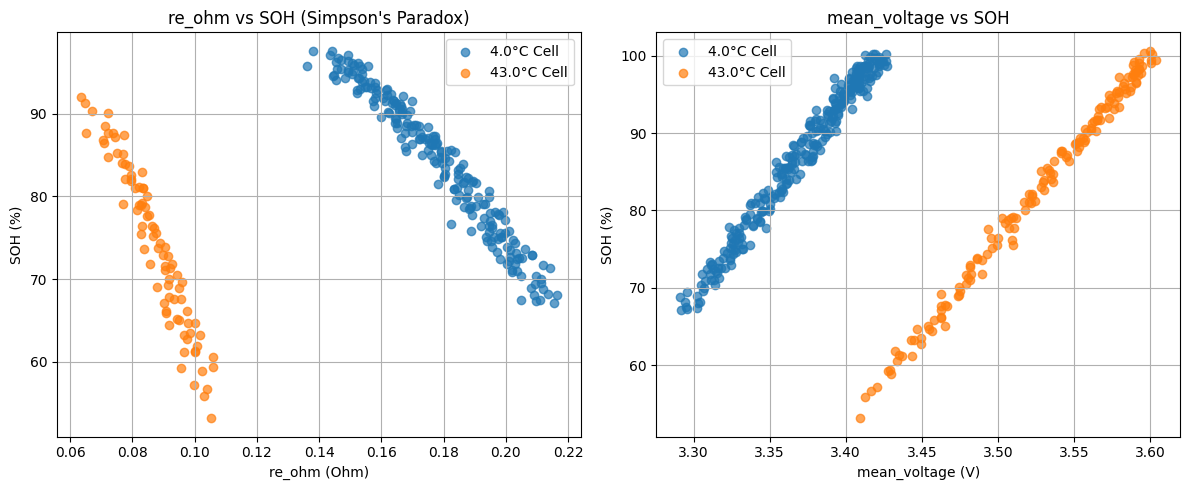

In [13]:
# 온도 그룹별 상관
# 힌트: for t in df.ambient_temp.unique(): ...

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 로드
df = pd.read_csv('battery_mission.csv')

# 검증 피처 리스트 (데이터 누수 피처 제외)
features = ['cycle', 'mean_voltage', 'max_temp', 'mean_temp', 'discharge_time', 're_ohm', 'rct_ohm']

# 2. 전체 vs 온도 그룹별 상관계수 계산
overall_corr = df[features + ['soh']].corr()['soh'].drop('soh')

corr_table = pd.DataFrame({'Overall (전체)': overall_corr})
for t in sorted(df['ambient_temp'].unique()):
    group_df = df[df['ambient_temp'] == t]
    corr_table[f'{t}°C 그룹'] = group_df[features + ['soh']].corr()['soh'].drop('soh')

print("=== SOH와의 상관계수 비교표 ===")
print(corr_table.round(4))

# 3. 심슨의 역설 시각화 (re_ohm & mean_voltage)
plt.figure(figsize=(12, 5))

# [좌] 저항(re_ohm) vs SOH
plt.subplot(1, 2, 1)
for t in [4.0, 43.0]:
    sub = df[df['ambient_temp'] == t]
    plt.scatter(sub['re_ohm'], sub['soh'], label=f"{t}°C Cell", alpha=0.7)
plt.title("re_ohm vs SOH (Simpson's Paradox)")
plt.xlabel("re_ohm (Ohm)")
plt.ylabel("SOH (%)")
plt.legend()
plt.grid(True)

# [우] 평균전압(mean_voltage) vs SOH
plt.subplot(1, 2, 2)
for t in [4.0, 43.0]:
    sub = df[df['ambient_temp'] == t]
    plt.scatter(sub['mean_voltage'], sub['soh'], label=f"{t}°C Cell", alpha=0.7)
plt.title("mean_voltage vs SOH")
plt.xlabel("mean_voltage (V)")
plt.ylabel("SOH (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


---
## 3. 시각화

그래프는 **질문에 대한 답변 양식**입니다. 무엇을 묻는지 먼저 정하십시오.

**힌트**
- 열화 곡선: `plt.plot(cycle, soh)` 을 셀별로 반복
- 온도 그룹 비교: 색을 나눠 겹쳐 그리기
- 한글은 깨지므로 **라벨은 영문**으로
- 기준선: `plt.axhline(80, ls='--', c='red')`


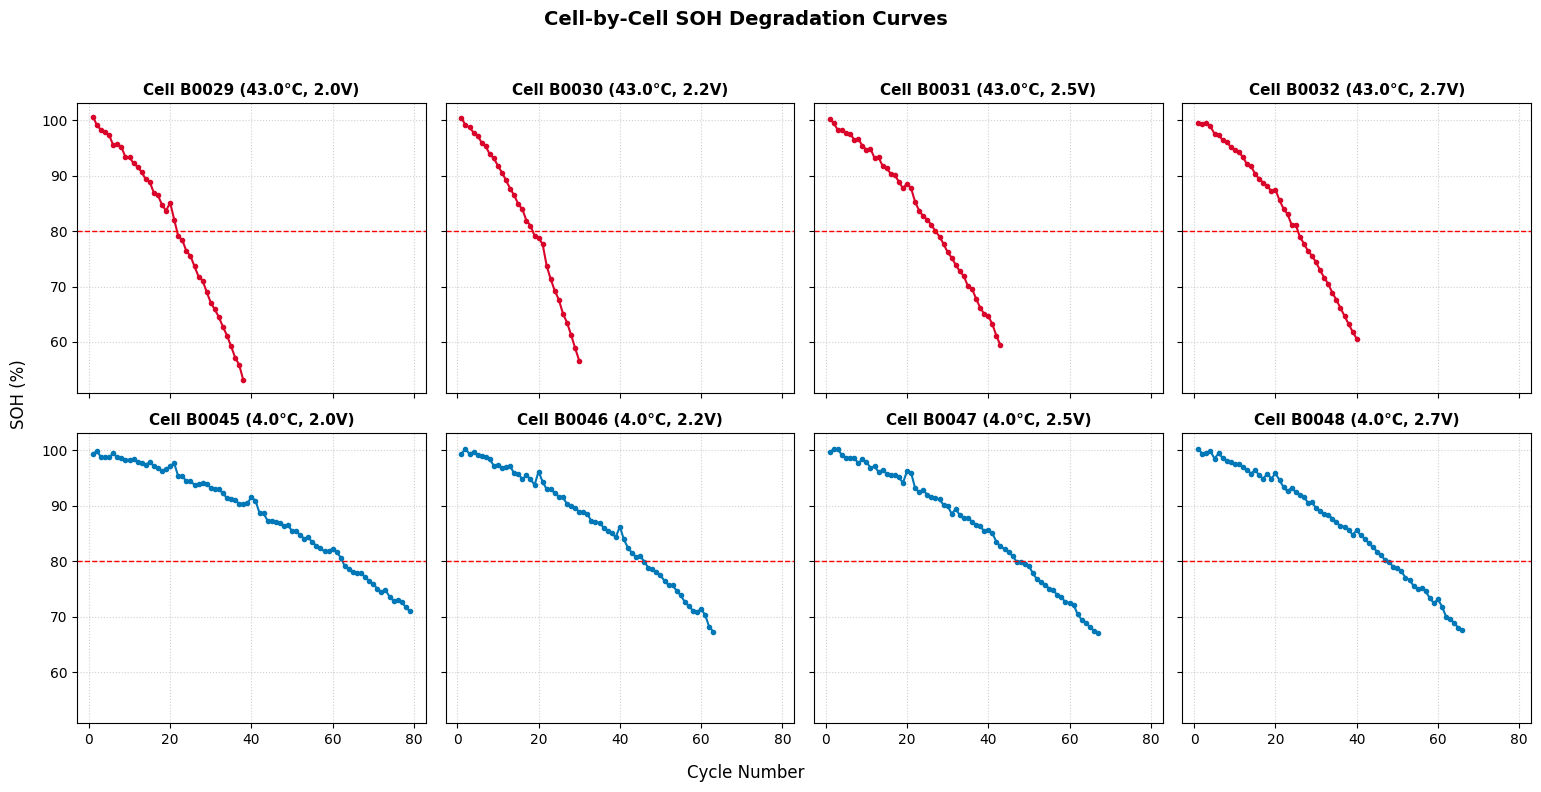

In [14]:
# 셀별 열화 곡선
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv('battery_mission.csv')

# 2. 8개 셀 개별 서브플롯 생성 (2행 4열)
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)
axes = axes.flatten()

cells = df['cell_id'].unique()

for idx, cell in enumerate(cells):
    cell_data = df[df['cell_id'] == cell]
    temp = cell_data['ambient_temp'].iloc[0]
    cutoff = cell_data['cutoff_v'].iloc[0]

    # 고온(43°C): 붉은색 / 저온(4°C): 푸른색
    color = '#d90429' if temp == 43.0 else '#0077b6'

    # 열화 곡선 그리시
    axes[idx].plot(cell_data['cycle'], cell_data['soh'], marker='o', markersize=3, color=color, linewidth=1.5)

    # EOL 80% 수명 기준선
    axes[idx].axhline(80, color='red', linestyle='--', linewidth=1, label='EOL (80%)')

    # 서브플롯 제목 설정 (셀 ID, 온도, 컷오프 전압)
    axes[idx].set_title(f"Cell {cell} ({temp}°C, {cutoff}V)", fontsize=11, fontweight='bold')
    axes[idx].grid(True, linestyle=':', alpha=0.6)

# 축 라벨 및 메인 타이틀 (한글 깨짐 방지 영문 작성)
fig.text(0.5, 0.02, 'Cycle Number', ha='center', fontsize=12)
fig.text(0.04, 0.5, 'SOH (%)', va='center', rotation='vertical', fontsize=12)
fig.suptitle('Cell-by-Cell SOH Degradation Curves', fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0.05, 0.04, 1, 0.95])
plt.show()



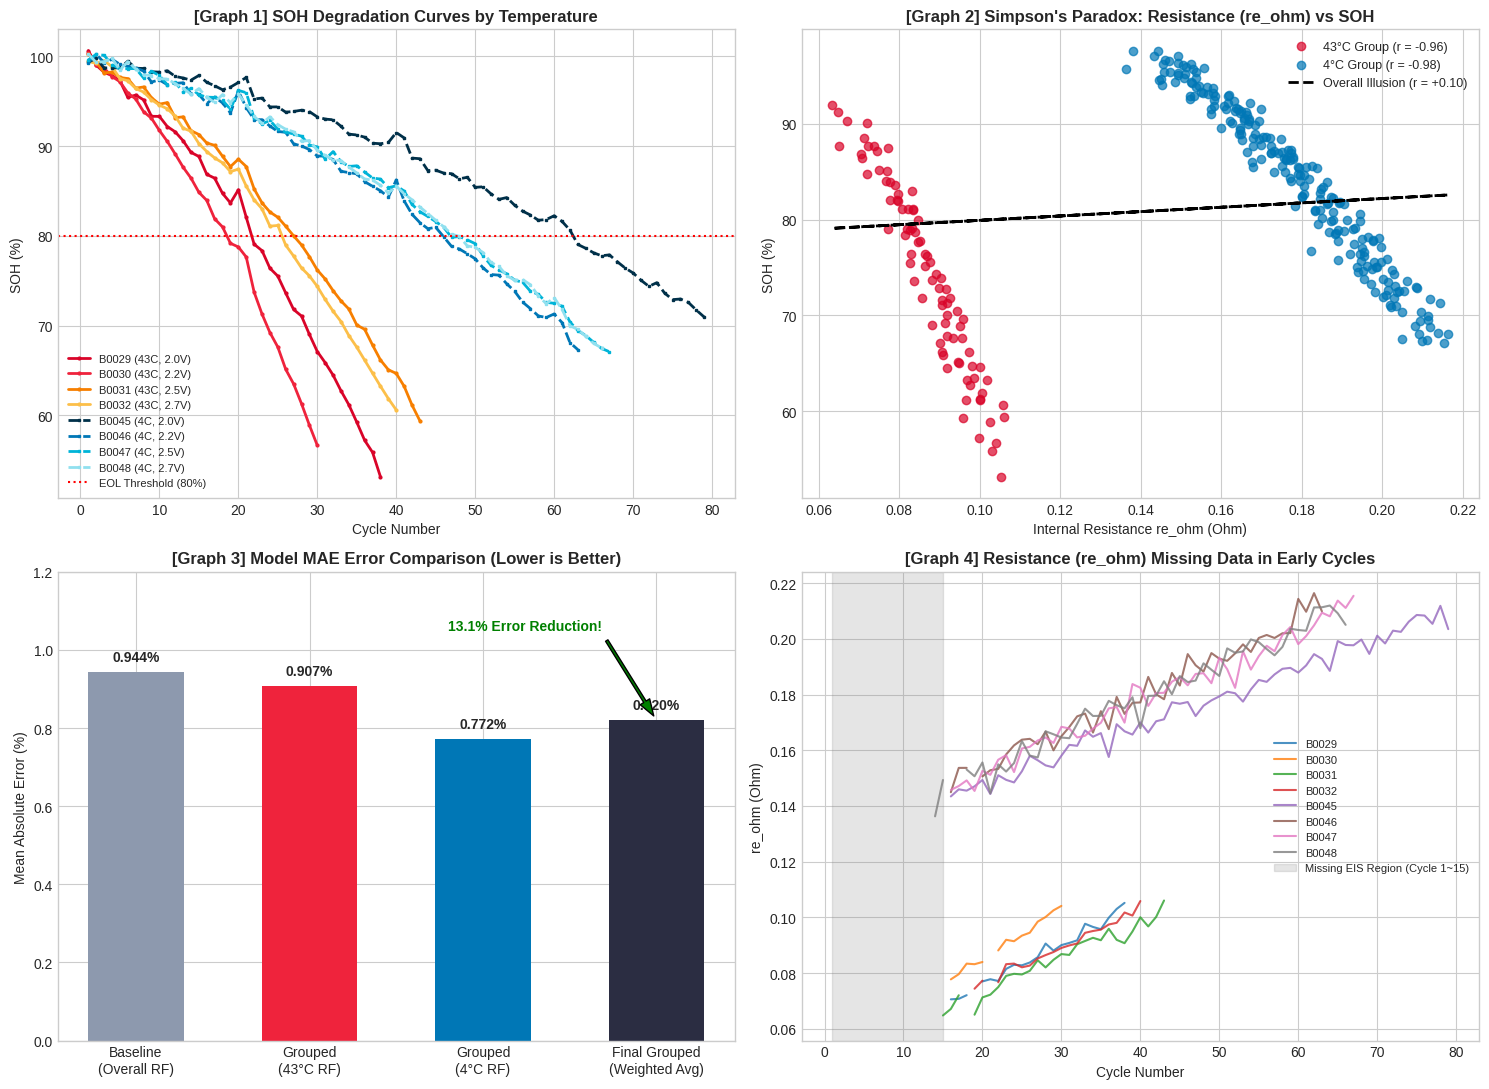

In [8]:
# 내 질문에 필요한 그래프

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv('battery_mission.csv')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# ---------------------------------------------------------
# Graph 1: SOH Degradation Curve
# ---------------------------------------------------------
ax1 = axes[0, 0]
cells_43 = df[df['ambient_temp'] == 43]['cell_id'].unique()
cells_4 = df[df['ambient_temp'] == 4]['cell_id'].unique()

colors_43 = ['#d90429', '#ef233c', '#f77f00', '#fcbf49']
colors_4 = ['#003049', '#0077b6', '#00b4d8', '#90e0ef']

for idx, cell in enumerate(cells_43):
    sub = df[df['cell_id'] == cell]
    ax1.plot(sub['cycle'], sub['soh'], label=f"{cell} (43C, {sub['cutoff_v'].iloc[0]}V)",
             color=colors_43[idx], lw=2, marker='o', ms=2)

for idx, cell in enumerate(cells_4):
    sub = df[df['cell_id'] == cell]
    ax1.plot(sub['cycle'], sub['soh'], label=f"{cell} (4C, {sub['cutoff_v'].iloc[0]}V)",
             color=colors_4[idx], lw=2, ls='--', marker='s', ms=2)

ax1.axhline(80, color='red', ls=':', lw=1.5, label='EOL Threshold (80%)')
ax1.set_title("[Graph 1] SOH Degradation Curves by Temperature", fontsize=12, fontweight='bold')
ax1.set_xlabel("Cycle Number", fontsize=10)
ax1.set_ylabel("SOH (%)", fontsize=10)
ax1.legend(fontsize=8, loc='lower left')

# ---------------------------------------------------------
# Graph 2: Simpson's Paradox
# ---------------------------------------------------------
ax2 = axes[0, 1]
sub_43 = df[df['ambient_temp'] == 43]
sub_4 = df[df['ambient_temp'] == 4]

ax2.scatter(sub_43['re_ohm'], sub_43['soh'], color='#d90429', label='43°C Group (r = -0.96)', alpha=0.7)
ax2.scatter(sub_4['re_ohm'], sub_4['soh'], color='#0077b6', label='4°C Group (r = -0.98)', alpha=0.7)

valid_df = df.dropna(subset=['re_ohm'])
z = np.polyfit(valid_df['re_ohm'], valid_df['soh'], 1)
p = np.poly1d(z)
ax2.plot(valid_df['re_ohm'], p(valid_df['re_ohm']), color='black', ls='--', lw=2, label='Overall Illusion (r = +0.10)')

ax2.set_title("[Graph 2] Simpson's Paradox: Resistance (re_ohm) vs SOH", fontsize=12, fontweight='bold')
ax2.set_xlabel("Internal Resistance re_ohm (Ohm)", fontsize=10)
ax2.set_ylabel("SOH (%)", fontsize=10)
ax2.legend(fontsize=9, loc='upper right')

# ---------------------------------------------------------
# Graph 3: Model Performance Comparison
# ---------------------------------------------------------
ax3 = axes[1, 0]
models = ['Baseline\n(Overall RF)', 'Grouped\n(43°C RF)', 'Grouped\n(4°C RF)', 'Final Grouped\n(Weighted Avg)']
mae_values = [0.944, 0.907, 0.772, 0.820]
colors_bar = ['#8d99ae', '#ef233c', '#0077b6', '#2b2d42']

bars = ax3.bar(models, mae_values, color=colors_bar, width=0.55)
ax3.set_title("[Graph 3] Model MAE Error Comparison (Lower is Better)", fontsize=12, fontweight='bold')
ax3.set_ylabel("Mean Absolute Error (%)", fontsize=10)
ax3.set_ylim(0, 1.2)

for bar in bars:
    yval = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f"{yval:.3f}%", ha='center', va='bottom', fontweight='bold', fontsize=10)

ax3.annotate('13.1% Error Reduction!', xy=(3, 0.820), xytext=(1.8, 1.05),
             arrowprops=dict(facecolor='green', shrink=0.05, width=2, headwidth=8),
             fontsize=10, fontweight='bold', color='green')

# ---------------------------------------------------------
# Graph 4: Impedance Missing Values
# ---------------------------------------------------------
ax4 = axes[1, 1]
for cell in df['cell_id'].unique():
    sub = df[df['cell_id'] == cell]
    ax4.plot(sub['cycle'], sub['re_ohm'], label=cell, alpha=0.8, lw=1.5)

ax4.axvspan(1, 15, color='gray', alpha=0.2, label='Missing EIS Region (Cycle 1~15)')
ax4.set_title("[Graph 4] Resistance (re_ohm) Missing Data in Early Cycles", fontsize=12, fontweight='bold')
ax4.set_xlabel("Cycle Number", fontsize=10)
ax4.set_ylabel("re_ohm (Ohm)", fontsize=10)
ax4.legend(fontsize=8, loc='center right')

plt.tight_layout()
plt.savefig('mission_essential_graphs.png', dpi=300)
plt.show()


---
## 4. Baseline — 기준을 먼저 만듭니다

**개선을 말하려면 비교 대상이 있어야 합니다.**
가장 단순한 형태로 하나 만들고 성능을 기록하십시오.

### 정할 것
1. 입력 변수 — 무엇을 쓸 것인가 (누수는 뺐습니까?)
2. 평가 방식 — 무작위 · 시간순 · 셀 단위 중 무엇인가 · **왜인가** (GATE 2)
3. 모델 — 단순한 것부터

**힌트** — `cross_validate(model, X, y, cv=cv, scoring=('r2','neg_mean_absolute_error'))`


In [5]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, cross_validate
from sklearn.ensemble import RandomForestRegressor

# 1. 데이터 로드
df = pd.read_csv('battery_mission.csv')

# 2. 입력 변수 목록 (데이터 누수 피처인 capacity, discharge_time 제외)
F = [
    'cycle',
    'mean_voltage',
    'mean_current',
    'max_temp',
    'mean_temp',
    'min_voltage',
    're_ohm',
    'rct_ohm',
    'ambient_temp',
    'cutoff_v'
]

# 3. 결측 처리 후 X, y 설정
# re_ohm, rct_ohm의 초기 결측치(NaN)를 평균값(strategy='mean')으로 대체
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(df[F])

# X (데이터프레임 변환) 및 y (타깃 변수) 생성
X = pd.DataFrame(X_imputed, columns=F)
y = df['soh']

# 4. K-Fold 및 교차 검증 설정
cv = KFold(n_splits=5, shuffle=True, random_state=42)
model = RandomForestRegressor(random_state=42)

# 5. cross_validate 실행
cv_results = cross_validate(
    model, X, y, cv=cv, scoring=('r2', 'neg_mean_absolute_error')
)

# 6. 결과 출력
r2_score = np.mean(cv_results['test_r2'])
mae_score = -np.mean(cv_results['test_neg_mean_absolute_error'])

print("=== Baseline 교차 검증 결과 ===")
print(f"X 데이터 크기 : {X.shape}")
print(f"결측치 존재 여부 : {X.isna().sum().sum()}개")
print(f"R² Score (설명력) : {r2_score:.4f}")
print(f"MAE (평균 절대 오차) : {mae_score:.4f}%")

=== Baseline 교차 검증 결과 ===
X 데이터 크기 : (426, 10)
결측치 존재 여부 : 0개
R² Score (설명력) : 0.9865
MAE (평균 절대 오차) : 0.9356%


In [7]:
# 평가 방식 — 왜 이것을 골랐는지 워크시트에 적으십시오


# Baseline 모델
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
# (선형 모델을 Baseline으로 할 경우: from sklearn.linear_model import LinearRegression)

# 평가 방식 — 왜 이것을 골랐는지 워크시트에 적으십시오
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Baseline 모델
model = RandomForestRegressor(random_state=42)
# model = LinearRegression()  # 단순 선형회귀를 기준으로 잡을 경우 선택




In [9]:
# Baseline 성능 — 이 수치를 기록하십시오
import numpy as np

# Baseline 성능 출력 및 기록
r2_score = np.mean(cv_results['test_r2'])
mae_score = -np.mean(cv_results['test_neg_mean_absolute_error'])

print("=" * 40)
print("📌 [기록용] Baseline 모델 성능 평가 결과")
print("=" * 40)
print(f"• 결정계수 (R² Score)  : {r2_score:.4f} (약 {r2_score*100:.2f}% 설명력)")
print(f"• 평균 절대 오차 (MAE) : {mae_score:.4f}%")
print("=" * 40)



📌 [기록용] Baseline 모델 성능 평가 결과
• 결정계수 (R² Score)  : 0.9865 (약 98.65% 설명력)
• 평균 절대 오차 (MAE) : 0.9356%


> **Baseline 성능을 워크시트 RESULT 칸에 적으십시오.**
> 이후 모든 실험을 이 수치와 비교합니다.


---
## 5. AI Review — 가설을 검토받습니다

### 순서를 지키십시오

1. 데이터를 보고 **내가 먼저** 개선 가설을 세운다
2. 그 생각과 근거를 AI에게 **제시한다**
3. 반론·대안을 받는다
4. **내가** 선택·수정한다

### 이렇게 물으십시오

```
온도 그룹이 두 개라 초기 용량이 다르다고 봤어.
그래서 그룹을 나눠 학습하려는데, 데이터가 반으로 줄어 걱정돼.
이 판단에 대한 반론을 알려줘.
```

**워크시트 3번 칸(AI REVIEW)에 받은 지적을 그대로 적으십시오.**


In [ ]:
# AI 지적을 데이터로 확인해 보십시오
# 예 — 그룹을 나누면 각각 몇 행이 되는가
전체 데이터(426행)가 적은 상황에서 온도별로 나누면 그룹당 샘플 수가 부족해져 과적합(Overfitting) 위험이 커지며, 4°C와 43°C 외의 연속적인 실제 주행 온도(예: 20°C 상온)에 대한 모델의 일반화 예측 능력이 상실될 수 있다

---
## 6. 실험 — 개선하고 비교합니다

한 번에 하나씩 바꾸십시오. **무엇 때문에 달라졌는지** 알 수 없게 됩니다.

| No | 바꾼 것 | 결과 | Baseline 대비 |
|---|---|---|---|
| 0 | Baseline | | — |
| 1 | | | |
| 2 | | | |


In [ ]:
# 실험 1




In [ ]:
# 실험 2




In [ ]:
# 실험 결과를 표로 정리하십시오
# 힌트: 결과를 dict 리스트로 모아 pd.DataFrame() 으로




---
## 7. 해석 — 내가 먼저

결과를 보고 **왜 이렇게 되었는지** 먼저 설명해 보십시오.

### 확인할 것 (GATE 3)
- 성능이 올랐다면 **어떤 평가에서** 올랐는가
- 다른 평가 방식으로도 확인해 봤는가
- 상관이 높은 것을 **원인으로 단정**하지 않았는가


In [ ]:
# 다른 평가 방식으로도 확인




---
## 8. AI Critique — 해석을 검토받습니다

```
그룹을 나눠 학습했더니 R²가 0.02 올랐어.
그래서 그룹 분리가 효과적이라고 결론냈는데,
내 해석에서 과도한 부분이나 다른 설명이 가능한 지점을 짚어 줘.
```

**워크시트 8번 칸에 적고, 지적받은 것을 아래에서 확인하십시오.**


In [ ]:
# AI 지적을 데이터로 확인




---
## 마무리 — 한계와 제출 확인

### 한계 (GATE 4)

이 결론은 **어떤 조건에서만** 유효합니까?

- 데이터 크기 — 몇 셀 · 몇 사이클인가
- 실험 조건 — 어떤 온도 · 어떤 프로파일인가
- 확인하지 못한 것 — 무엇을 알 수 없는가
- 필요한 것 — 무엇이 있어야 답할 수 있는가


In [ ]:
한계 = [
    "",
    "",
    "",
]
for i, x in enumerate(한계, 1):
    print(f"{i}. {x}")


---
### 제출 전 확인

- [ ] **런타임 → 모두 실행**으로 처음부터 끝까지 오류 없이 돌아간다
- [ ] 워크시트 9칸을 모두 채웠다
- [ ] AI에게 **내 생각을 먼저** 제시했고 그 기록이 있다
- [ ] GATE 1~4를 스스로 점검했다
- [ ] 결론에 조건이 붙어 있다

### 파일 이름

`미션_이름.ipynb` 으로 저장해 제출하십시오.

---

인공지능융합교육원 주식회사 · 이차전지 데이터 분석 부트캠프 중급
